# Meta Analysis of Gene expression in Colorectal Cancer

Johan Rosgaard

03/03/2026

## Import libraries used.

In [2]:
# Main module
%reset -f

# autoreload imports
%load_ext autoreload
%autoreload 2

## CIBERSORT code

In [3]:
import csv
import json
import os
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from functools import partial
from itertools import repeat

import numpy as np
import numba
np.set_printoptions(linewidth=15000)

import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.animation as animation
import matplotlib as mpl
from matplotlib.colors import Normalize
import seaborn as sns

from tabulate import tabulate
from tqdm import tqdm

import copy
import statistics as stat
from scipy import stats
from io import StringIO
import scipy.stats as stats
from scipy.stats import spearmanr
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
from scipy.optimize import brentq
from IPython.display import display, HTML

print(os.getcwd())
plt.style.use('seaborn-v0_8-colorblind')

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

try:
    import psutil
except Exception:
    psutil = None

try:
    import lxml
except Exception:
    lxml = None

# Custom colormap for heatmaps
from matplotlib.colors import LinearSegmentedColormap
colors = ["dimgray", "darkred"]
scarlet_gray_cmap = LinearSegmentedColormap.from_list("RedGray", colors, N=512)

# Check versions of key libraries
print("\nNumPy version:", np.__version__)
print("Numba version:", numba.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

/Users/johanrosgaard/Documents/Undergraduate Thesis/ELISA data/ELISA_python_workspace/TCGA_gene_exp

NumPy version: 1.26.4
Numba version: 0.59.1
Pandas version: 2.3.3
Matplotlib version: 3.10.8


In [4]:
def printmem() -> None:
    """Print current process RSS memory in GB (requires psutil)."""
    if psutil is None:
        print("psutil not available; cannot report memory.")
        return
    process = psutil.Process(os.getpid())
    rss_gb = round(process.memory_info().rss / 1e9, 3)
    print(f"Memory usage: {rss_gb} GB")

def nested_defaultdict(default_factory, depth: int = 1):
    """
    Create a nested defaultdict of arbitrary depth.
    """
    if depth < 1:
        raise ValueError("depth must be >= 1")
    result = partial(defaultdict, default_factory)
    for _ in repeat(None, depth - 1):
        result = partial(defaultdict, result)
    return result()

# Shannon entropy per sample
def shannon_entropy(p):
    p = p[p > 0]
    return -np.sum(p * np.log2(p))


## Set universal controls

In [5]:
# Change the default colormap for heatmaps
cmap = 'coolwarm'
print("\ncmap set to:", cmap)

"""Diagnostic mode will print additional information to help verify that data is being processed correctly
# Set to false to disable verification prints"""
diagnostic_mode = False

if diagnostic_mode == True:
    import diagnostic_mode
    print("\n*** DIAGNOSTIC MODE ON. ***")
else:
    print("\n*** DIAGNOSTIC MODE OFF. ***")



cmap set to: coolwarm

*** DIAGNOSTIC MODE OFF. ***


## Genes of Interest (GOI)

***Colorectal prognostic markers were taken from:***

Niu, L., Gao, C. & Li, Y. Identification of potential core genes in colorectal carcinoma and key genes in colorectal cancer liver metastasis using bioinformatics analysis. Sci Rep 11, 23938 (2021). https://doi.org/10.1038/s41598-021-03395-5

Mubarak, S. J. & Vedagiri, H. Identification of gene signatures and transcription factors associated with colorectal cancer through computational based approach. Human Gene 44, 201405 (2025). https://doi.org/10.1016/j.humgen.2025.201405

Matsui, A., Yamaguchi, T., Maekawa, S., Miyazaki, C., Takano, S., Uetake, T., Inoue, T., Otaka, M., Otsuka, H., Sato, T., Yamashita, A., Takahashi, Y., & Enomoto, N. (2009). DICKKOPF-4 and -2 genes are upregulated in human colorectal cancer. Cancer science, 100(10), 1923–1930. https://doi.org/10.1111/j.1349-7006.2009.01272.x


In [6]:
# Genes of Interest
GOI = ['PTK2','STING1','NFKB1','IRF3','IFNG','TGFB1', 'TGFB2','ACTA2',
       'CCL2','CCL5','IL6', 'CXCL8','CXCL9','CXCL10','CXCL11','CXCL12',
       'GZMB','ICAM1','VEGFA', 'VIM','CD274','AKT1']

CRC_prognostic_markers = ['COL1A2', 'AURKA', 'GCG', 'TIMP1', 'ITIH2', 'FGA', 'HPX',
                          'AHSG', 'SERPINC1', 'F2', 'CP', 'APOA2', 'PLG', 'HRG',
                          'CXCL1', 'MMP1', 'UBE2C', 'CXCL12', 'TOP2A', 'ALDH1A1', 'PRKACB',
                          'DKK2', 'DKK4',
                          'RGMB', 'MND1', 'CBX2', 'GDPD5', 'DUSP15', 'SPC25', 'SPP1',
                          'RNF183', 'PRMT3', 'NOTCH3', 'CPNE7','GDPD5', 'DSCC1', 'KLHL35', 'SPC25']

# FAK axis genes, including key signaling molecules and downstream effectors
FAK_axis_genes = ['PTK2', 'AKT1', 'PIK3CD', 'PIK3R1', 'KDR', 'VCAM1', 'IL33']

# STING axis genes, including key signaling molecules and downstream effectors
"""
STING1 and TMEM173 refer to the same protein.
NF-kB1 is the gene encoding the p50 subunit of NF-kB a transcription factor activated downstream.
"""
STING_axis_genes = ['STING1', 'TBK1', 'NFKB1', 'IRF3', 'IL1B', 'IFNB1']

# Genes associated with cytotoxic immune cell recruitment and activation
cytotoxic_recruiting_genes = ['CXCL9', 'CXCL10', 'CXCL11', 'CXCL12', 
                              'CCL4', 'CCL5', 'CCL20',
                              'IFNG'
                              ]

# Markers of NK cell activation
NKcell_recruiting_markers = ['GZMB', 'PRF1','NKG7']

# Genes associated with immunosuppressive cell recruitment and activation
immunosuppressive_recruiting_genes = ['TGFB1', 'TGFB2',
                                      'CXCL2', 'CXCL5', 'CXCL6',
                                      'CXCL8',          # IL8 is the same as CXCL8
                                      'CXCL12',
                                      'CCL2',
                                      'CCL17',
                                      'CCL22',
                                      'IL6', 
                                      'CD274']

# Genes associated with fibroblast activation, CAF, and EMT
fibroblast_activation_markers = ['ACTA2', 'VIM', 'ICAM1', 'FAP', 'COL1A1', 'COL1A2', 'COL3A1']

# Matrixmetalloproteinases
MMP_genes = ['MMP1', 'MMP2', 'MMP3', 'MMP7', 'MMP9', 'MMP13', 'MMP14']

# Angiogenesis-related genes
angiogenesis_genes = ['VEGFA', 'KDR']

# All genes of interest for correlation analysis
all_GOI = list(set(GOI + 
                    CRC_prognostic_markers +
                    FAK_axis_genes +
                    STING_axis_genes + 
                    cytotoxic_recruiting_genes +
                    NKcell_recruiting_markers +
                    immunosuppressive_recruiting_genes +
                    fibroblast_activation_markers +
                    MMP_genes))

# Complete list of genes for correlation analysis
all_genes_for_correlation = list(set(FAK_axis_genes + 
                                     STING_axis_genes + 
                                     cytotoxic_recruiting_genes + 
                                     NKcell_recruiting_markers + 
                                     immunosuppressive_recruiting_genes + 
                                     fibroblast_activation_markers + 
                                     MMP_genes))

## Pull data

Using TPM unstranded expression.

In [7]:
# Create empty list to store data
full_data = []
subset_data = []

# Directory containing the expression files
file_directory = "/Users/johanrosgaard/Documents/Expression Data/TCGA_COAD_exp"

# Loop through each folder in the directory
for folder in tqdm(os.listdir(file_directory)):
    folder_path = os.path.join(file_directory, folder)
    if not os.path.isdir(folder_path):
        continue

    # Pull the expression file in the folder
    files = [f for f in os.listdir(folder_path) if f.endswith(".tsv")]
    if not files:
        continue

    file_path = os.path.join(folder_path, files[0])
    df = pd.read_csv(file_path, sep="\t", comment="#")

    # Save full data with gene names as columns and sample_id as index
    df_full = df[["gene_name", "tpm_unstranded"]].dropna(subset=["gene_name", "tpm_unstranded"])
    df_full = df_full.groupby("gene_name", as_index=True)["tpm_unstranded"].mean().to_frame().T
    df_full["gdc_file_id"] = folder
    df_full["file_name"] = files[0]
    full_data.append(df_full)

    # Make subset with genes of interest
    df_subset = df[df["gene_name"].isin(GOI)][["gene_name", "tpm_unstranded"]].dropna(subset=["gene_name", "tpm_unstranded"])
    df_subset = df_subset.groupby("gene_name", as_index=True)["tpm_unstranded"].mean().to_frame().T
    df_subset["gdc_file_id"] = folder
    df_subset["file_name"] = files[0]
    subset_data.append(df_subset)

# Combine full data into one DataFrame
full_expr = pd.concat(full_data)
full_expr = full_expr.set_index("gdc_file_id")

# Combine subset data into one DataFrame
subset_expr = pd.concat(subset_data)
subset_expr = subset_expr.set_index("gdc_file_id")

# Copy full and subset data for log transformation
full_expr_log = full_expr.copy()
subset_expr_log = subset_expr.copy()

# Log-transform the expression data using log(x+1) to avoid log(0)
full_expr_log.iloc[:, :-1] = np.log2(full_expr_log.iloc[:, :-1] + 1)
subset_expr_log.iloc[:, :-1] = np.log2(subset_expr_log.iloc[:, :-1] + 1)

if diagnostic_mode == True:
    # Print shapes of the resulting DataFrames
    print("Full expression data shape:", full_expr_log.shape)
    print("Subset expression data shape:", subset_expr.shape)

100%|██████████| 696/696 [00:40<00:00, 17.13it/s]


In [8]:
# Remove index name for cleaner display
full_expr_log.columns.name = None
subset_expr_log.columns.name = None

## Map file name to sample_id

In [9]:
# Manifest file path
manifest_path = "/Users/johanrosgaard/Documents/Expression Data/gdc_manifest.2026-03-03.121221.txt"
manifest_df = pd.read_csv(manifest_path, sep="\t")

# Reset index
full_expr_log = full_expr_log.reset_index()
subset_expr_log = subset_expr_log.reset_index()


if diagnostic_mode == True:
    # Print first few columns to verify
    print(full_expr_log.columns[:5].tolist())
    print(subset_expr_log.columns[:5].tolist())

In [10]:
# Load metadata cart
metacart_path = "/Users/johanrosgaard/Documents/Expression Data/metadata.cart.2026-03-08.json"

# Parse metadata cart to extract file_id, file_name, aliquot_barcode, sample_barcode, and case_id
with open(metacart_path) as f:
    metadata = json.load(f)

rows = []

for entry in metadata:
    file_name = entry["file_name"]
    file_id = entry["file_id"]

    if entry["associated_entities"]:
        entity = entry["associated_entities"][0]
        aliquot_barcode = entity["entity_submitter_id"]
        case_id = entity["case_id"]
        sample_barcode = aliquot_barcode[:16]  # TCGA-AA-3561-01A

        rows.append({
            "file_name": file_name,
            "file_id": file_id,
            "aliquot_barcode": aliquot_barcode,
            "sample_barcode": sample_barcode,
            "case_id": case_id
        })

mapping_df = pd.DataFrame(rows)

if diagnostic_mode == True:
    print(mapping_df.columns.tolist())
    print(mapping_df.shape)
    print(mapping_df.head())
    print("Overlap on gdc_file_id/file_id:", len(set(full_expr_log["gdc_file_id"]) & set(mapping_df["file_id"])))
    print("Overlap on file_name:", len(set(full_expr_log["file_name"]) & set(mapping_df["file_name"])))

In [11]:
# Merge full_expr
full_expr_log = full_expr_log.merge(mapping_df,left_on="gdc_file_id",right_on="file_id",how="left")

# Merge subset_expr
subset_expr_log = subset_expr_log.merge(mapping_df,left_on="gdc_file_id",right_on="file_id",how="left")

# Drop redundant columns and rename for clarity
full_expr_log = full_expr_log.drop(columns=["file_name_y"]).rename(columns={"file_name_x": "file_name"})
subset_expr_log = subset_expr_log.drop(columns=["file_name_y"]).rename(columns={"file_name_x": "file_name"})

if diagnostic_mode == True:
    # Print verification
    print(full_expr_log[["gdc_file_id", "file_id", "file_name", "aliquot_barcode", "sample_barcode", "case_id"]].head())
    print("Missing sample_barcode in full_expr_log:", full_expr_log["sample_barcode"].isna().sum())
    print("Missing sample_barcode in subset_expr_log:", subset_expr_log["sample_barcode"].isna().sum())

## Save data to CSV

In [12]:
#print(os.getcwd())

# Save the full expression data to a CSV file
full_expr_log.to_csv("full_expression_data_log_transformed.csv")
print("Full expression data saved to full_expression_data_log_transformed.csv")


Full expression data saved to full_expression_data_log_transformed.csv


In [13]:
# Open the full expression data CSV file
#full_expr = open("full_expression_data.csv", "r").close()

## Pull clinical data

In [14]:
# Path to clinical data file
clinical_file_path = '/Users/johanrosgaard/Documents/Expression Data/TCGA_COAD_metadata/clinical.project-tcga-coad.2026-03-03/clinical.tsv'

# Load clinical data into a DataFrame
clinical_data = pd.read_csv(clinical_file_path, sep='\t')

if diagnostic_mode == True:
    # Print shape and columns of clinical data for verification
    print("Clinical data shape:", clinical_data.shape)
    print("Clinical data columns:", clinical_data.columns)

## Save clinical data to CSV

In [15]:
# Save the full clinical data to a CSV file
clinical_data.to_csv("full_clinical_data.csv")
print("Full clinical data saved to full_clinical_data.csv")

Full clinical data saved to full_clinical_data.csv


In [16]:
# Create a new column for overall survival time in days, using days_to_death if available, otherwise days_to_last_follow_up
clinical_data["survival_days"] = clinical_data["demographic.days_to_death"].fillna(
    clinical_data["diagnoses.days_to_last_follow_up"])

clinical_data["outcome"] = clinical_data["demographic.vital_status"]
clinical_data["stage_group"] = clinical_data["diagnoses.ajcc_pathologic_stage"]
clinical_data["recurrence"] = clinical_data["diagnoses.progression_or_recurrence"]
clinical_data["case_id"] = clinical_data["cases.case_id"]

if diagnostic_mode == True:
    print("Samples in clinical data:", clinical_data["case_id"].nunique())
    print("Unique values in stage_group:", clinical_data["stage_group"].unique())
    print("")
    print("clinical_data columns contains case_id:", "case_id" in clinical_data.columns)
    print("clinical_data columns:", clinical_data.columns.tolist()[:20])

## CIBERSORT

In [17]:
# List of immune cell populations from CIBERSORT
immune_cell_populations = ["B.cells.naive", "B.cells.memory",
                           "Plasma.cells",
                           "T.cells.CD8", "T.cells.CD4.naive", "T.cells.CD4.memory.resting", "T.cells.CD4.memory.activated", "T.cells.follicular.helper", "T.cells.regulatory..Tregs.", "T.cells.gamma.delta",
                           "NK.cells.resting", "NK.cells.activated",
                           "Monocytes",
                           "Macrophages.M0", "Macrophages.M1", "Macrophages.M2",
                           "Dendritic.cells.resting", "Dendritic.cells.activated",
                           "Mast.cells.resting", "Mast.cells.activated",
                           "Eosinophils",
                           "Neutrophils"]

# Cytotoxic and anti-tumor immune cell populations
cytotoxic_immune_populations = ["T.cells.CD8", 
                                "NK.cells.activated", "NK.cells.resting",
                                "T.cells.gamma.delta", 
                                "T.cells.CD4.memory.activated", "T.cells.follicular.helper",
                                "Dendritic.cells.activated", "Dendritic.cells.resting",
                                "Macrophages.M1"]

# Immunosuppressive and pro-tumor immune cell populations
immunosuppressive_immune_populations = ["T.cells.regulatory..Tregs.",
                                        "Macrophages.M2", 
                                        "Monocytes",
                                        "Neutrophils",
                                        "Mast.cells.activated", "Mast.cells.resting"]

In [18]:
# Directory containing the expression files
file_path_cibersort = "/Users/johanrosgaard/Documents/Expression Data/CIBERSORT/TCGA.Kallisto.fullIDs.cibersort.relative.tsv"

# Open the CIBERSORT  file
cibersort_df = pd.read_csv(file_path_cibersort, sep="\t", comment="#")

# Contains: 
# SampleID, CancerType, 
# B.cells.naive, B.cells.memory, 
# Plasma.cells, 
# T.cells.CD8, T.cells.CD4.naive, T.cells.CD4.memory.resting, T.cells.CD4.memory.activated, T.cells.follicular.helper, T.cells.regulatory..Tregs., T.cells.gamma.delta, 
# NK.cells.resting, NK.cells.activated, 
# Monocytes, 
# Macrophages.M0, Macrophages.M1, Macrophages.M2, 
# Dendritic.cells.resting, Dendritic.cells.activated, 
# Mast.cells.resting, Mast.cells.activated, 
# Eosinophils, 
# Neutrophils, 
# P.value, Correlation, RMSE

# Save full data with gene names as columns and sample_id as index
cibersort_df_full = cibersort_df.copy()

# Extract sample_id from SampleID
cibersort_df_full["sample_id"] = cibersort_df_full["SampleID"].str.replace(".", "-", regex=False)

# Set sample_id as index
CIBERSORT_data = cibersort_df_full.set_index("sample_id")

# Filter CIBERSORT data for colorectal cancer samples (COAD and READ)
CRC_CIBERSORT_data = CIBERSORT_data[CIBERSORT_data["CancerType"].isin(["COAD", "READ"])]
CRC_CIBERSORT_data = CRC_CIBERSORT_data.copy()
CRC_CIBERSORT_data.index.name = None

if diagnostic_mode == True:
    # Print first 10 sample IDs for verification
    print(cibersort_df["SampleID"].head(10).tolist())
    # Print shapes of the resulting DataFrames
    print("CIBERSORT data shape:", CIBERSORT_data.shape)
    print("\nCRC CIBERSORT data shape:", CRC_CIBERSORT_data.shape)
    print(CRC_CIBERSORT_data["CancerType"].value_counts())

In [19]:
# Sort by Treg fraction
CRC_CIBERSORT_data.sort_values("T.cells.regulatory..Tregs.", ascending=False).head(10)

# Copy both dataframes (log transformed)
full_expr_CIBERSORT = full_expr_log.copy()
CRC_CIBERSORT_data = CRC_CIBERSORT_data.copy()

# Key
full_expr_CIBERSORT["sample_id"] = full_expr_CIBERSORT["aliquot_barcode"].str[:16]
CRC_CIBERSORT_data["sample_id"] = CRC_CIBERSORT_data.index.str[:16]

if diagnostic_mode == True:
    print("Pre-merge sample_id:")
    print(full_expr_CIBERSORT["sample_id"].head(10).tolist())
    print(CRC_CIBERSORT_data["sample_id"].head(10).tolist())

# Merge full expression data with CIBERSORT data on SampleID
expr_cs_merged = full_expr_CIBERSORT.merge(CRC_CIBERSORT_data,on="sample_id",how="inner")

if diagnostic_mode == True:
    print("Merged expression and CIBERSORT data shape:", expr_cs_merged.shape)
    print("Merged data columns:", expr_cs_merged.columns.tolist()[:20])
    print(expr_cs_merged[["PTK2", "T.cells.regulatory..Tregs."]].head())

set1 = set(full_expr_CIBERSORT["sample_id"])
set2 = set(CRC_CIBERSORT_data["sample_id"])

print("Overlap:", len(set1 & set2))
print("Expression sample_ids:", full_expr_CIBERSORT["sample_id"].nunique())
print("CIBERSORT sample_ids:", CRC_CIBERSORT_data["sample_id"].nunique())

if diagnostic_mode == True:
    print(full_expr_CIBERSORT["aliquot_barcode"].head(10).tolist())
    print(full_expr_CIBERSORT["sample_id"].head(10).tolist())
    print(CRC_CIBERSORT_data.index[:10].tolist())
    print(CRC_CIBERSORT_data["sample_id"].head(10).tolist())

Overlap: 685
Expression sample_ids: 685
CIBERSORT sample_ids: 691


In [20]:
if diagnostic_mode == True:
    print("Number of unique sample_ids in merged data:", expr_cs_merged["sample_id"].nunique())
    print("Number of rows in merged data:", expr_cs_merged.shape[0])
    print("Number of duplicated sample_ids in merged data:", expr_cs_merged["sample_id"].duplicated().sum())

# Average the expression values for duplicated samples
expr_cs_merged = (expr_cs_merged.groupby("sample_id", as_index=False).mean(numeric_only=True))

if diagnostic_mode == True:
    print("\nRows after deduplication:", expr_cs_merged.shape)
    print("Unique sample_ids:", expr_cs_merged["sample_id"].nunique())

In [21]:
# Create a list to store correlation results
gene_to_immune_cell_correlation_results = []

# Loop through genes and immune cell populations to calculate Spearman correlation
for immune_population in immune_cell_populations:

    for gene in all_genes_for_correlation:

        if gene not in expr_cs_merged.columns:
            continue
        
        sub_df = expr_cs_merged[[gene, immune_population]].dropna()

        if sub_df.empty:
            continue

        # Calculate Spearman correlation
        rho_value, p_value = spearmanr(sub_df[gene], sub_df[immune_population])

        gene_to_immune_cell_correlation_results.append({"gene": gene,
                                                        "immune_population": immune_population,
                                                        "correlation": rho_value,
                                                        "p_value": p_value,
                                                        "n": len(sub_df)})

# Convert to DataFrame
gene_to_immune_cell_correlation = pd.DataFrame(gene_to_immune_cell_correlation_results)

# Print number of correlations for each category
for category, cell_population in {"cytotoxic": cytotoxic_immune_populations,
                                       "immunosuppressive": immunosuppressive_immune_populations}.items():
        gene_to_immune_category = gene_to_immune_cell_correlation[
             gene_to_immune_cell_correlation["immune_population"].isin(cell_population)]
        
        print(f"Number of gene correlations for {category}: {len(gene_to_immune_category)}")

if diagnostic_mode == True:
    print("")
    print(gene_to_immune_cell_correlation.sort_values("correlation", ascending=False).head(10))

Number of gene correlations for cytotoxic: 441
Number of gene correlations for immunosuppressive: 294


## Spearman correlation matrices for selected genes sets

In [22]:
# Show or hide plots
show_plots = True

In [23]:
# Spearman correlation matrix for the full expression data
# This will be a large matrix (genes x genes), so will take time to compute
big_correlation_matrix = full_expr_log[all_GOI].corr(method="spearman")
big_correlation_mask = np.eye(len(big_correlation_matrix), dtype=bool)

print("Correlation matrix computed. Shape:", big_correlation_matrix.shape)

if diagnostic_mode == True:
    print("Full expression log 10 columns:", full_expr_log.columns[:10].tolist())
    print("Subset expression log 10 columns:", subset_expr_log.columns[:10].tolist())
    print("Big correlation matrix head:")
    print(big_correlation_matrix.head())


Correlation matrix computed. Shape: (83, 83)


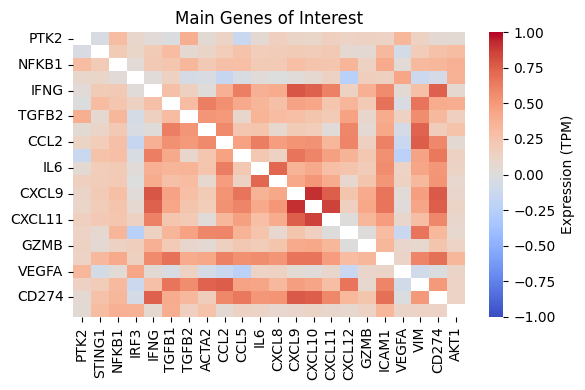

In [24]:
# Spearman correlation matrix
corr_matrix_subset = subset_expr_log[GOI].corr(method="spearman")
mask_matrix_subset = np.eye(len(corr_matrix_subset), dtype=bool)

# Plot heatmap of the correlation matrix for the genes of interest
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix_subset, mask=mask_matrix_subset, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='g', cbar_kws={'label': 'Expression (TPM)'})
plt.title('Main Genes of Interest')

#plt.savefig('GOI_exp_heatmap_1.png', dpi=1000, bbox_inches='tight')
plt.tight_layout()

if show_plots == True:
    plt.show()

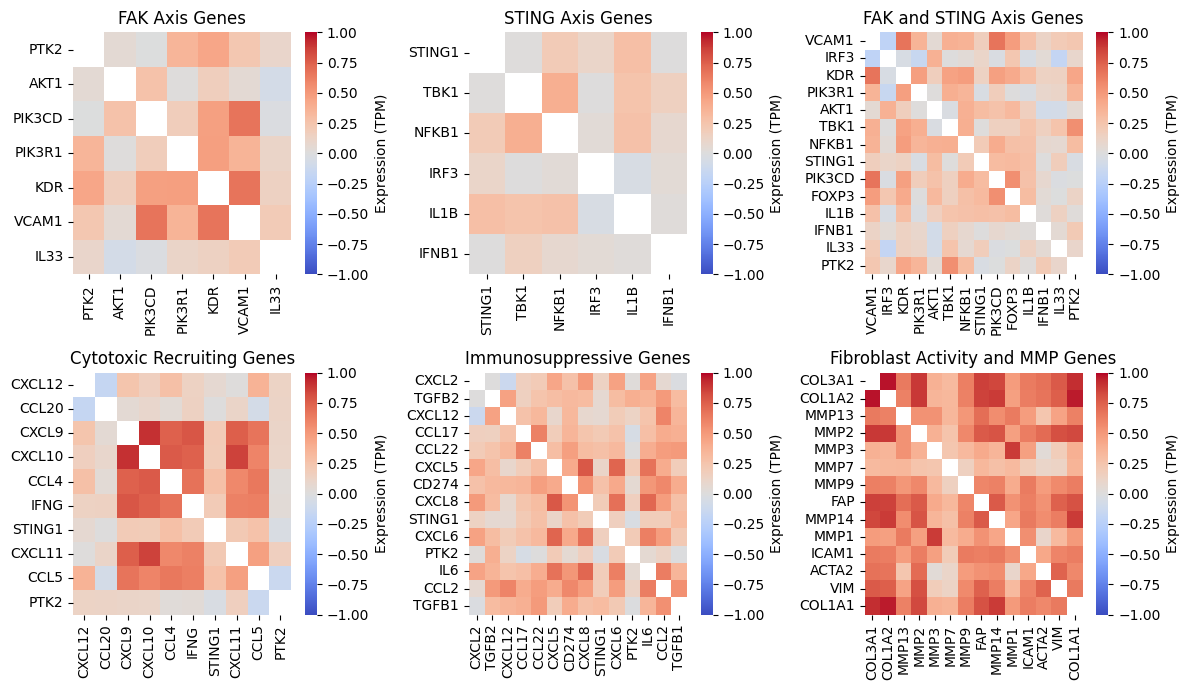

In [25]:
# Start figure
plt.figure(figsize=(12, 7))

# Define a diverging colormap
cmap = sns.color_palette("coolwarm", as_cmap=True)
annot = False

# Correlation matrix for FAK axis genes
corr_matrix_FAK = full_expr_log[FAK_axis_genes].corr(method="spearman")
mask_matrix_FAK = np.eye(len(corr_matrix_FAK), dtype=bool)

plt.subplot(2,3,1)
sns.heatmap(corr_matrix_FAK, mask=mask_matrix_FAK, annot=annot, cmap=cmap, fmt='g', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Expression (TPM)'})
plt.title('FAK Axis Genes')

# Correlation matrix for STING axis genes
corr_matrix_STING = full_expr_log[STING_axis_genes].corr(method="spearman")
mask_matrix_STING = np.eye(len(corr_matrix_STING), dtype=bool)

plt.subplot(2,3,2)
sns.heatmap(corr_matrix_STING, mask=mask_matrix_STING, annot=annot, cmap=cmap, fmt='g', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Expression (TPM)'})
plt.title('STING Axis Genes')


# Correlation matrix for combined FAK and STING axis genes
FAK_STING_genes = list(set(FAK_axis_genes + STING_axis_genes + ['FOXP3']))
corr_matrix_FAK_STING = full_expr_log[FAK_STING_genes].corr(method="spearman")
mask_matrix_FAK_STING = np.eye(len(corr_matrix_FAK_STING), dtype=bool)

plt.subplot(2,3,3)
sns.heatmap(corr_matrix_FAK_STING, mask=mask_matrix_FAK_STING, annot=annot, cmap=cmap, fmt='g', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Expression (TPM)'})
plt.title('FAK and STING Axis Genes')

# Correlation matrix for cytotoxic recruiting genes
cytotoxic_plus_recruiting_genes = list(set(cytotoxic_recruiting_genes + ['PTK2', 'STING1']))
corr_matrix_cytotoxic = full_expr_log[cytotoxic_plus_recruiting_genes].corr(method="spearman")
mask_matrix_cytotoxic = np.eye(len(corr_matrix_cytotoxic), dtype=bool)

plt.subplot(2,3,4)
sns.heatmap(corr_matrix_cytotoxic, mask=mask_matrix_cytotoxic, annot=annot, cmap=cmap, fmt='g', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Expression (TPM)'})
plt.title('Cytotoxic Recruiting Genes')

# Correlation matrix for immunosuppressive genes
immunosuppressive_plus_recruiting_genes = list(set(immunosuppressive_recruiting_genes + ['PTK2', 'STING1']))
corr_matrix_immunosuppressive = full_expr_log[immunosuppressive_plus_recruiting_genes].corr(method="spearman")
mask_matrix_immunosuppressive = np.eye(len(corr_matrix_immunosuppressive), dtype=bool)

plt.subplot(2,3,5)
sns.heatmap(corr_matrix_immunosuppressive, mask=mask_matrix_immunosuppressive, annot=annot, cmap=cmap, fmt='g', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Expression (TPM)'})
plt.title('Immunosuppressive Genes')

# Correlation matrix for fibroblasts activity and MMP genes
FB_MMP_genes = list(set(fibroblast_activation_markers + MMP_genes))
corr_matrix_FB_MMP = full_expr_log[FB_MMP_genes].corr(method="spearman")
mask_matrix_FB_MMP = np.eye(len(corr_matrix_FB_MMP), dtype=bool)

plt.subplot(2,3,6)
sns.heatmap(corr_matrix_FB_MMP, mask=mask_matrix_FB_MMP, annot=annot, cmap=cmap, fmt='g', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Expression (TPM)'})
plt.title('Fibroblast Activity and MMP Genes')

#plt.savefig('FAK_axis_genes_exp_heatmap.png', dpi=1000, bbox_inches='tight')
plt.tight_layout()

if show_plots == True:
    plt.show()

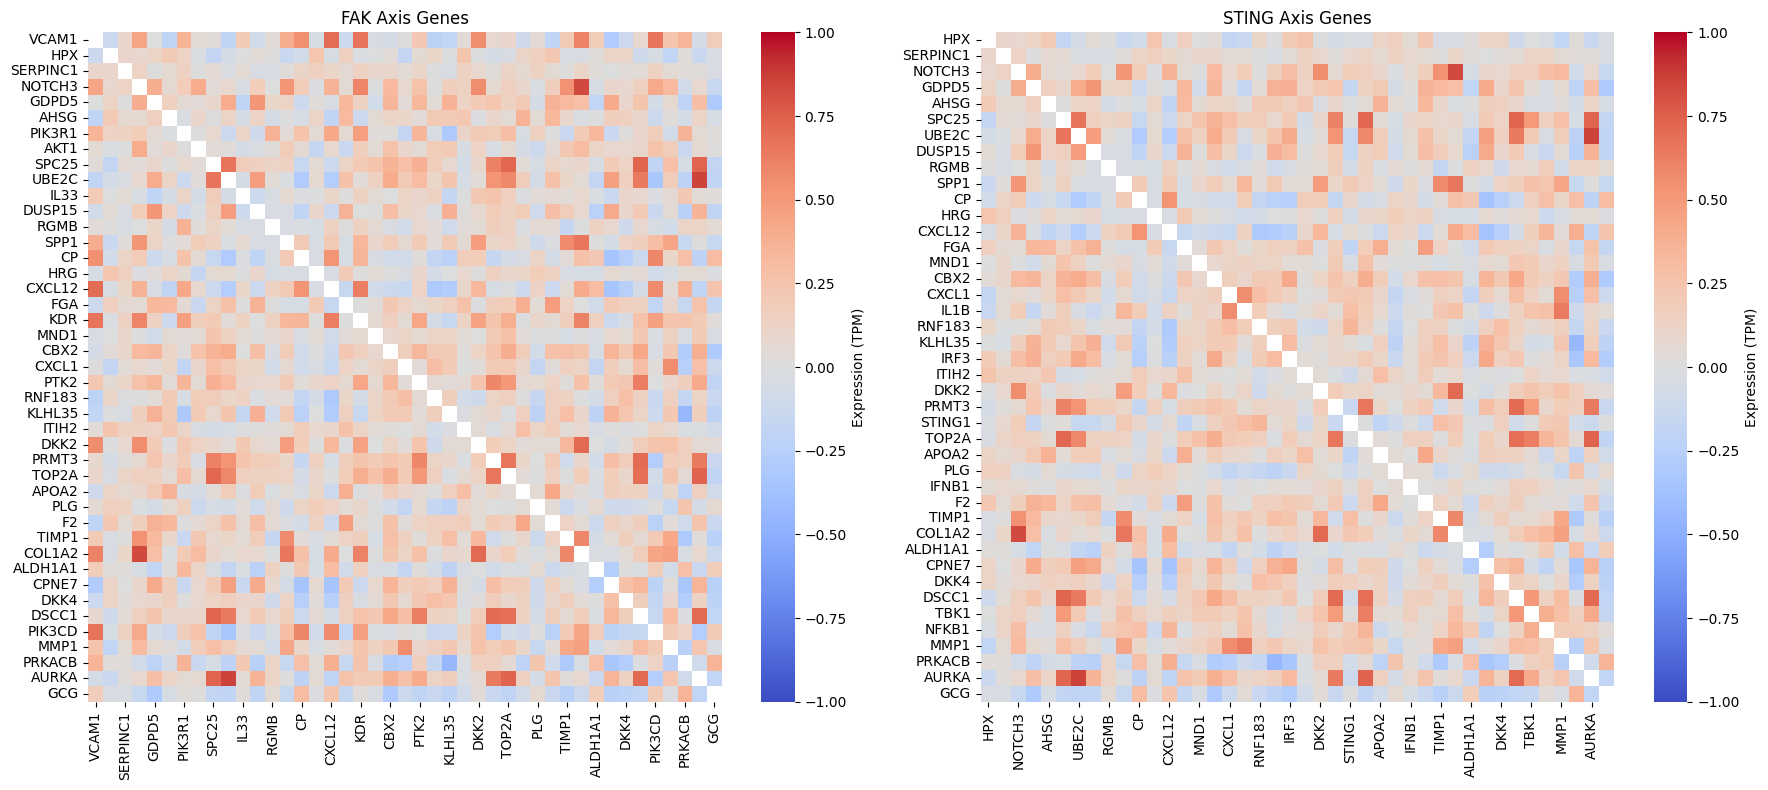

In [26]:
# Start figure
plt.figure(figsize=(18, 8))
cmap = sns.color_palette("coolwarm", as_cmap=True)

# Correlation matrix for FAK axis genes
FAK_prognostic_genes = list(set(FAK_axis_genes + CRC_prognostic_markers))
corr_matrix_FAK = full_expr_log[FAK_prognostic_genes].corr(method="spearman")
mask_matrix_FAK = np.eye(len(corr_matrix_FAK), dtype=bool)

plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix_FAK, mask=mask_matrix_FAK, annot=False, cmap=cmap, fmt='g', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Expression (TPM)'})
plt.title('FAK Axis Genes')

# Correlation matrix for STING axis genes
STING_prognostic_genes = list(set(STING_axis_genes + CRC_prognostic_markers))
corr_matrix_STING = full_expr_log[STING_prognostic_genes].corr(method="spearman")
mask_matrix_STING = np.eye(len(corr_matrix_STING), dtype=bool)

plt.subplot(1, 2, 2)
sns.heatmap(corr_matrix_STING, mask=mask_matrix_STING, annot=False, cmap=cmap, fmt='g', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Expression (TPM)'})
plt.title('STING Axis Genes')

#plt.savefig('FAK_axis_genes_exp_heatmap.png', dpi=1000, bbox_inches='tight')
plt.tight_layout()

if show_plots == True:
    plt.show()

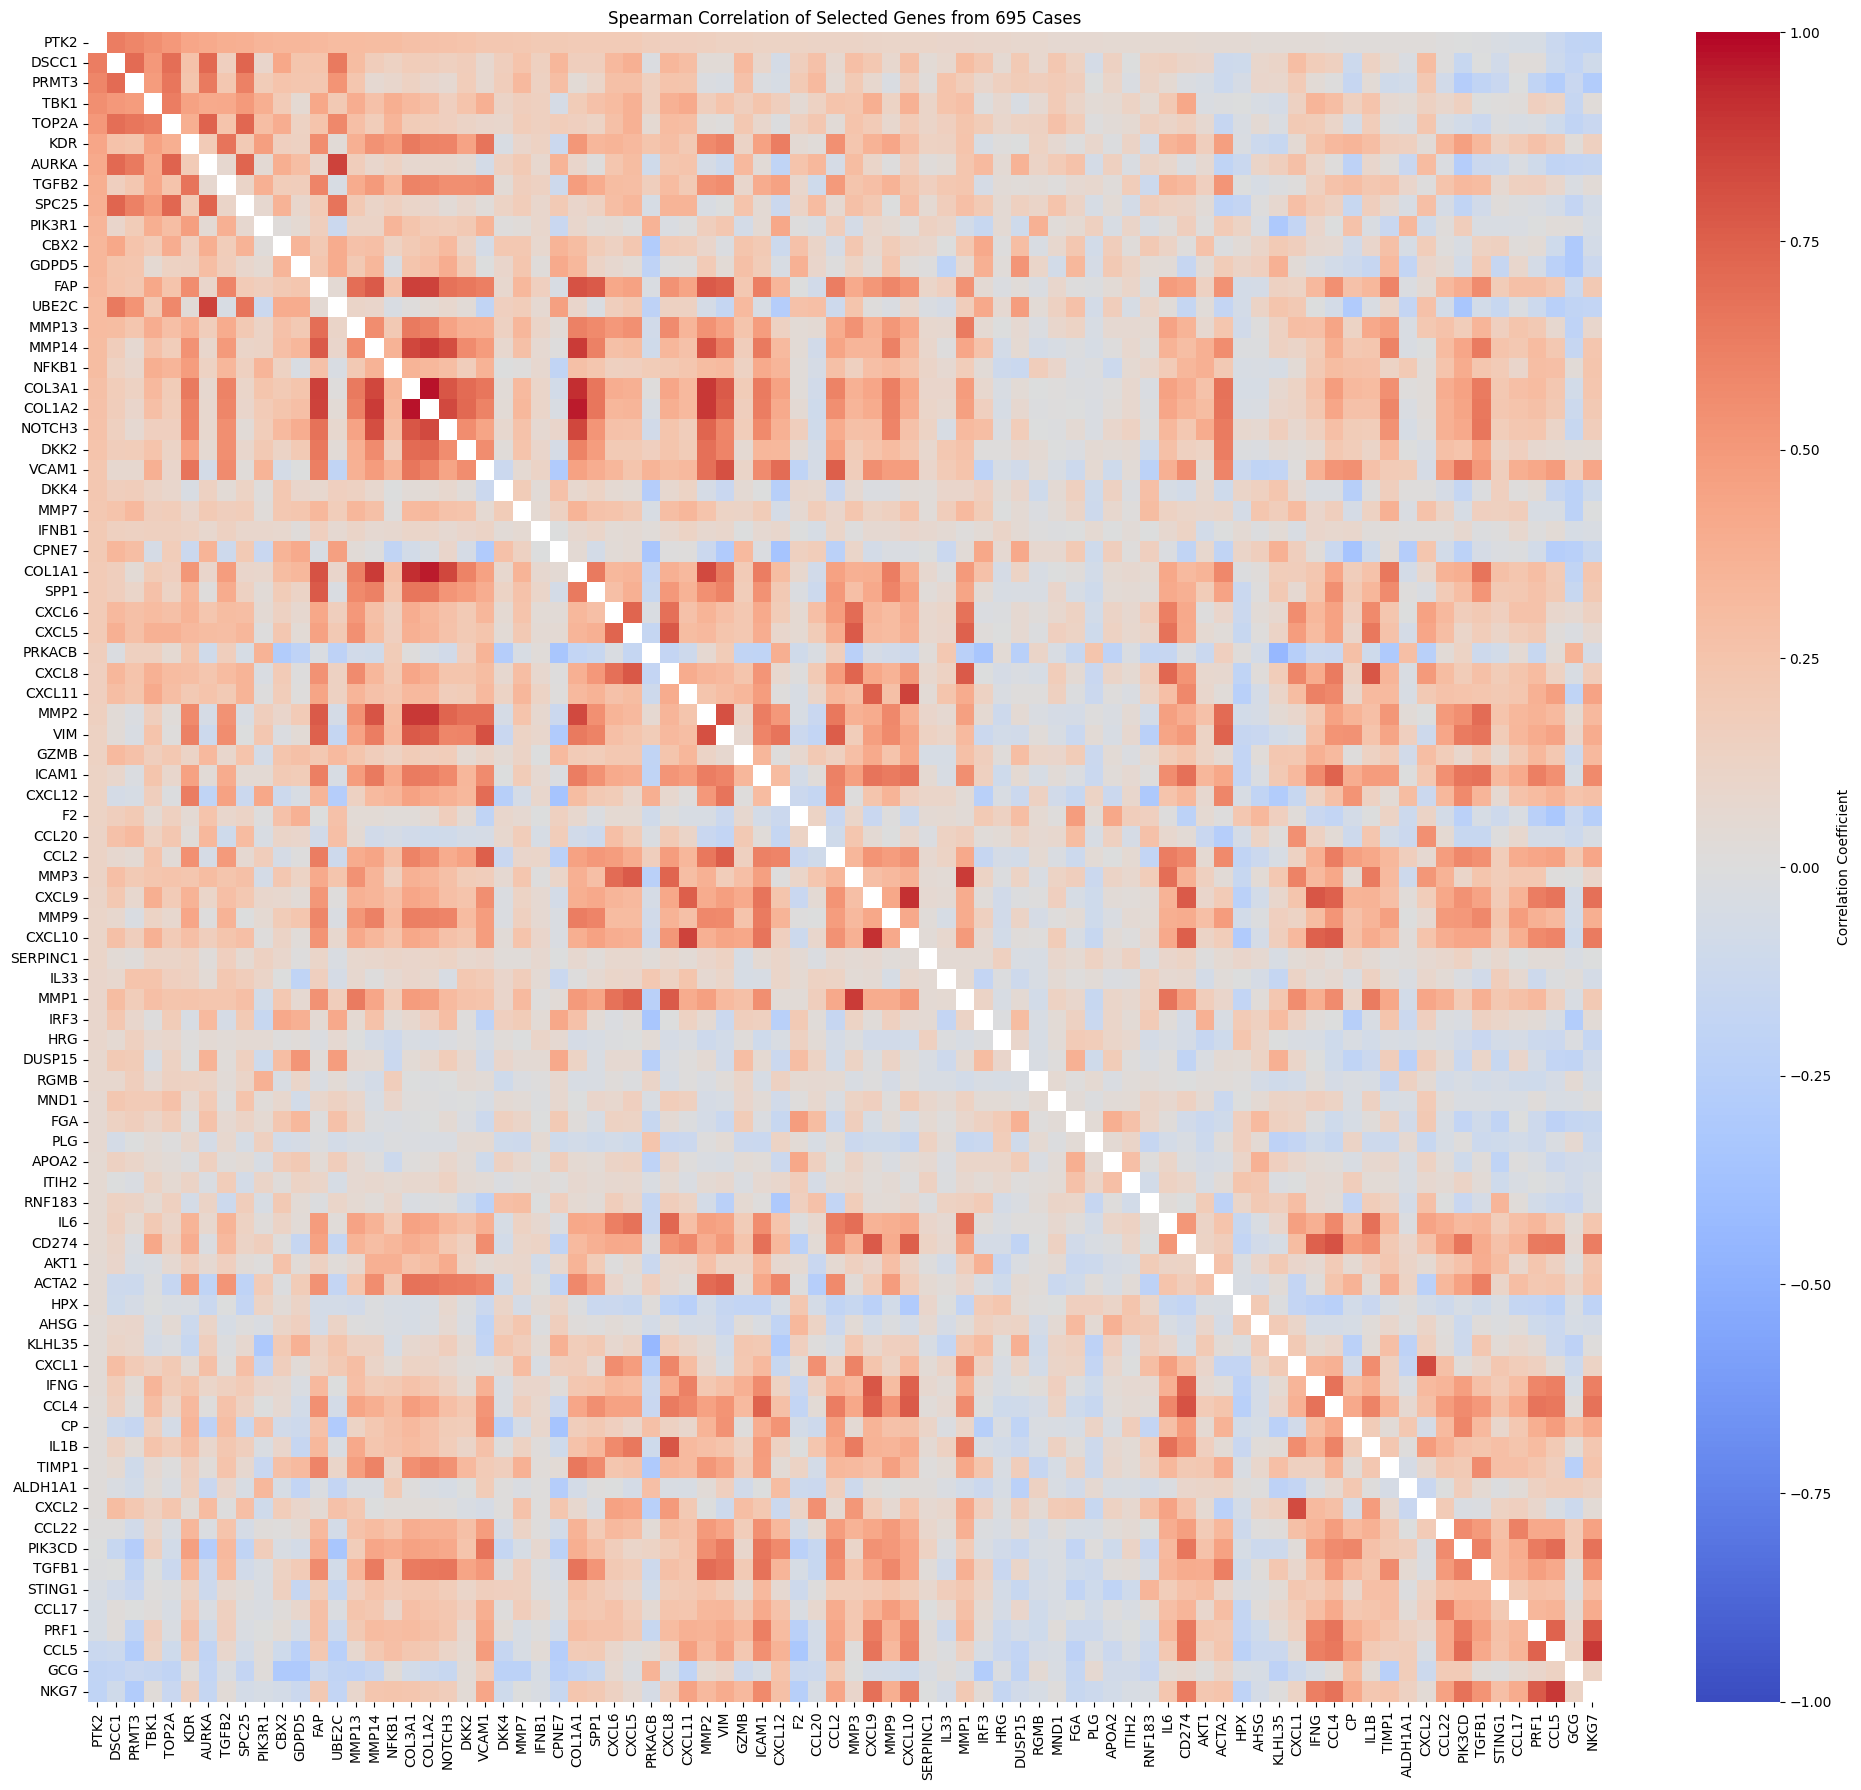

In [27]:
# Complete list of genes for correlation analysis
all_genes_mat = list(set(all_genes_for_correlation + CRC_prognostic_markers))

# Spearman correlation matrix
corr_matrix_all = full_expr_log[all_genes_mat].corr(method="spearman")
mask_matrix_all = np.eye(len(corr_matrix_all), dtype=bool)

ordering = corr_matrix_all["PTK2"].sort_values(ascending=False).index
corr_matrix_all = corr_matrix_all.loc[ordering, ordering]

plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix_all, mask=mask_matrix_all, annot=False, cmap='coolwarm', fmt='g', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Spearman Correlation of Selected Genes from 695 Cases')

plt.savefig('Spearman_Correlation_of_Selected_Genes_from_695_Cases.png', dpi=1000, bbox_inches='tight')
plt.tight_layout()

if show_plots == True:
    # This is a large heatmap
    plt.show()

In [28]:
# Toggle printing top correlations
# Change both to True to print top correlations
print_top_correlations = False
print_top_prognostic_marker_correlations = False

# Print top positively and negatively correlated genes with PTK2
sorted_PTK2_corr = corr_matrix_all["PTK2"].sort_values(ascending=False)

if print_top_correlations == True:
    print("Top 10 genes most positively correlated with PTK2:")
    print(sorted_PTK2_corr.head(10))
    print("Top 10 genes most negatively correlated with PTK2:")
    print(sorted_PTK2_corr.tail(10))

# Print top positively and negatively correlated genes with STING1
sorted_STING1_corr = corr_matrix_all["STING1"].sort_values(ascending=False)

if print_top_correlations == True:
    print("\nTop 10 genes most positively correlated with STING1:")
    print(sorted_STING1_corr.head(10))
    print("\nTop 10 genes most negatively correlated with STING1:")
    print(sorted_STING1_corr.tail(10))

if print_top_prognostic_marker_correlations == True:
    # Print correlations of PTK2 and STING1 with CRC prognostic markers, sorted by correlation coefficient
    print(sorted_PTK2_corr[CRC_prognostic_markers].sort_values(ascending=False).head(10))
    print(sorted_STING1_corr[CRC_prognostic_markers].sort_values(ascending=False).head(10))

    print("\nMean correlation of PTK2 with CRC prognostic markers:")
    print(sorted_PTK2_corr[CRC_prognostic_markers].sort_values(ascending=False).mean())
    print("\nMean correlation of STING1 with CRC prognostic markers:")
    print(sorted_STING1_corr[CRC_prognostic_markers].sort_values(ascending=False).mean())

In [29]:
# Toggle printing summary statistics of scores and entropy
# Change  to True to print
print_output = False

# Calculate scores for immunosuppressive and cytotoxic recruiting genes as grouped previously
immunosuppressive_score = (full_expr_log[immunosuppressive_recruiting_genes].mean(axis=1))
cytotoxic_score = (full_expr_log[cytotoxic_recruiting_genes].mean(axis=1))

# Get PTK2 and STING1 scores for each sample
PTK2_score = full_expr_log["PTK2"]
STING1_score = full_expr_log["STING1"]

# Calculate Shannon entropy for each sample across all genes used in the correlation analysis
entropy = (full_expr_log[all_genes_for_correlation].apply(shannon_entropy, axis=1))*(-1)

if print_output == True:
    # Print summary statistics of immunosuppressive and cytotoxic scores
    print("Immunosuppressive score summary:")
    print(immunosuppressive_score.describe())
    print("Cytotoxic score summary:")
    print(cytotoxic_score.describe())

    # Print summary statistics of the entropy values
    print("Entropy summary:")
    print(entropy.describe())

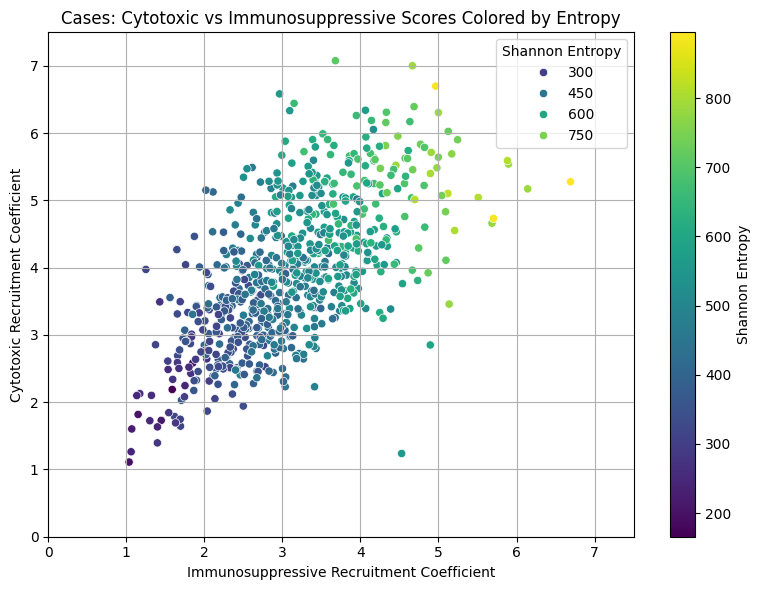

In [30]:
if show_plots == True:
    # Scatter plot of cytotoxic vs immunosuppressive scores colored by Shannon entropy
    plt.figure(figsize=(8, 6))
    ax = sns.scatterplot(x=immunosuppressive_score, y=cytotoxic_score, hue=entropy, hue_norm=(entropy.min(), entropy.max()), palette='viridis')

    norm = plt.Normalize(vmin=entropy.min(), vmax=entropy.max())
    sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Shannon Entropy")

    plt.title('Cases: Cytotoxic vs Immunosuppressive Scores Colored by Entropy')
    plt.xlabel('Immunosuppressive Recruitment Coefficient')
    plt.ylabel('Cytotoxic Recruitment Coefficient')
    plt.legend(title='Shannon Entropy')
    plt.xlim(0, 7.5)
    plt.ylim(0, 7.5)
    plt.grid(True)
    plt.tight_layout()

    plt.savefig('Cytotoxic_vs_Immunosuppressive_Scores_Colored_by_Entropy.png', dpi=1000, bbox_inches='tight')

    plt.show()

In [31]:
show_plots = False

if show_plots == True:
    # Scatter plot of cytotoxic vs immunosuppressive scores colored by Shannon entropy
    plt.figure(figsize=(4, 3))
    ax = sns.scatterplot(x=PTK2_score, y=STING1_score, hue=entropy, hue_norm=(entropy.min(), entropy.max()), palette='viridis')

    # Normalize the entropy values for the colorbar
    norm = Normalize(vmin=entropy.min(), vmax=entropy.max())
    sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Shannon Entropy")

    plt.title('Cases: PTK2 vs STING1 Scores Colored by Entropy')
    plt.xlabel('PTK2 Coefficient')
    plt.ylabel('STING1 Coefficient')
    plt.legend(title='Shannon Entropy')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Correlation between genes and immune cell populations.

As found earlier.

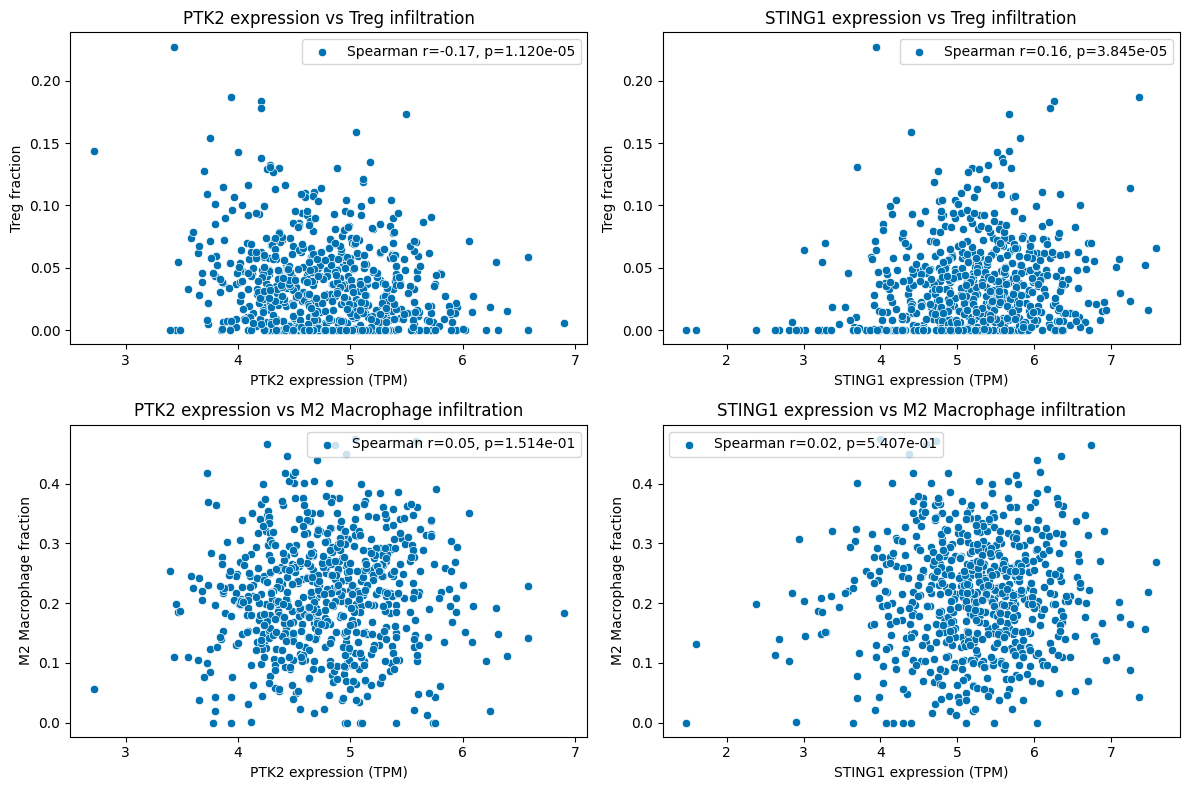

In [32]:
show_plots = True

if show_plots == True:

    plt.figure(figsize=(12, 8))

    plt.subplot(2,2,1)
    PTK2_Treg_correlation = spearmanr(expr_cs_merged["PTK2"], expr_cs_merged["T.cells.regulatory..Tregs."])
    sns.scatterplot(data=expr_cs_merged, x="PTK2", y="T.cells.regulatory..Tregs.")
    plt.xlabel("PTK2 expression (TPM)")
    plt.ylabel("Treg fraction")
    plt.title("PTK2 expression vs Treg infiltration")
    plt.legend(labels=[f"Spearman r={PTK2_Treg_correlation.correlation:.2f}, p={PTK2_Treg_correlation.pvalue:.3e}"])

    plt.subplot(2,2,2)
    STING1_Treg_correlation = spearmanr(expr_cs_merged["STING1"], expr_cs_merged["T.cells.regulatory..Tregs."])
    sns.scatterplot(data=expr_cs_merged, x="STING1", y="T.cells.regulatory..Tregs.")
    plt.xlabel("STING1 expression (TPM)")
    plt.ylabel("Treg fraction")
    plt.title("STING1 expression vs Treg infiltration")
    plt.legend(labels=[f"Spearman r={STING1_Treg_correlation.correlation:.2f}, p={STING1_Treg_correlation.pvalue:.3e}"])

    plt.subplot(2,2,3)
    PTK2_M2_correlation = spearmanr(expr_cs_merged["PTK2"], expr_cs_merged["Macrophages.M2"])
    sns.scatterplot(data=expr_cs_merged, x="PTK2", y="Macrophages.M2")
    plt.xlabel("PTK2 expression (TPM)")
    plt.ylabel("M2 Macrophage fraction")
    plt.title("PTK2 expression vs M2 Macrophage infiltration")
    plt.legend(labels=[f"Spearman r={PTK2_M2_correlation.correlation:.2f}, p={PTK2_M2_correlation.pvalue:.3e}"])

    plt.subplot(2,2,4)
    STING1_M2_correlation = spearmanr(expr_cs_merged["STING1"], expr_cs_merged["Macrophages.M2"])
    sns.scatterplot(data=expr_cs_merged, x="STING1", y="Macrophages.M2")
    plt.xlabel("STING1 expression (TPM)")
    plt.ylabel("M2 Macrophage fraction")
    plt.title("STING1 expression vs M2 Macrophage infiltration")
    plt.legend(labels=[f"Spearman r={STING1_M2_correlation.correlation:.2f}, p={STING1_M2_correlation.pvalue:.3e}"])

    plt.tight_layout()
    plt.show()

## Define two expression groups


***Groups:***

1. PTK2 high / STING1 low

2. PTK2 low / STING1 high

In [33]:
# Make a copy of the full expression data for subgroup analysis
full_expr_subgroups = full_expr_log.copy()
full_expr_subgroups["sample_id"] = full_expr_subgroups["sample_barcode"]

# Create a subset of the full expression data for the main genes of interest
target_genes_subset = full_expr_subgroups[['PTK2', 'STING1', 'sample_id']].copy()

# Threshold to define high and low expression groups for PTK2
ptk2_hi_threshold = target_genes_subset['PTK2'].quantile(0.75)
ptk2_lo_threshold = target_genes_subset['PTK2'].quantile(0.25)

# Threshold to define high and low expression groups for STING1
sting1_hi_threshold = target_genes_subset['STING1'].quantile(0.75)
sting1_lo_threshold = target_genes_subset['STING1'].quantile(0.25)

# Define PTK2 high / STING1 low group
ptk2_hi_sting1_low = target_genes_subset[(target_genes_subset['PTK2'] >= ptk2_hi_threshold) & 
                                         (target_genes_subset['STING1'] <= sting1_lo_threshold)]

# Define PTK2 low / STING1 high group
ptk2_lo_sting1_hi = target_genes_subset[(target_genes_subset['PTK2'] <= ptk2_lo_threshold) & 
                                        (target_genes_subset['STING1'] >= sting1_hi_threshold)]

# Print samples in each group
print("Total samples:", full_expr_log.shape[0])
print("PTK2 high, STING1 low group size:", ptk2_hi_sting1_low.shape[0])
print("PTK2 low, STING1 high group size:", ptk2_lo_sting1_hi.shape[0])

Total samples: 695
PTK2 high, STING1 low group size: 48
PTK2 low, STING1 high group size: 45


In [34]:
notable_genes = ["PTK2", "STING1", 
                 "PRF1", "GZMB", "IFNG", "NKG7",
                 "CXCL9", "CXCL10", "CXCL11", "IRF3",
                 "VEGFA", "KDF",
                 "TOP2A", "AURKA", "UBE2C", "SPC25", "DSCC1",
                "CXCL5", "CXCL6", "CCL20",
                "FAP", "VCAM1", "COL3A1", "COL1A2",
                "IL1B", "IL6", "CCL2",
                "DKK2", "GDPD5", "ICAM1"]

# Genes present in the dataframe
genes_present = [gene for gene in notable_genes if gene in full_expr_subgroups.columns]

# Pull expression for subgroups
ptk2_hi_sting1_low_expr = full_expr_subgroups.loc[ptk2_hi_sting1_low.index, genes_present]
ptk2_lo_sting1_hi_expr = full_expr_subgroups.loc[ptk2_lo_sting1_hi.index, genes_present]

# Mean expression per gene in each group
group_means_df = pd.DataFrame({"PTK2_high_STING1_low": ptk2_hi_sting1_low_expr.mean(),
                            "PTK2_low_STING1_high": ptk2_lo_sting1_hi_expr.mean()})

# Sort by difference in mean expression between the two groups
group_means_df["Difference"] = group_means_df["PTK2_high_STING1_low"] - group_means_df["PTK2_low_STING1_high"]
group_means_df.sort_values(by="Difference", ascending=False, inplace=True)

# Seperate the groups for plotting
plotted_ptk2_sting1_df = group_means_df[["PTK2_high_STING1_low", "PTK2_low_STING1_high"]].copy()

# Z scores
group_means_z = plotted_ptk2_sting1_df.apply(lambda row: (row - row.mean()) / row.std(ddof=0) if row.std(ddof=0) != 0 else 0, axis=1)

if diagnostic_mode == True:
    print("Group means range:")
    print(group_means_df.describe())

# Immune populations to target
targeted_immune_populations = list(set(cytotoxic_immune_populations + immunosuppressive_immune_populations))
#targeted_immune_populations = immune_cell_populations

# Correlate to cytotoxic and immunosuppressive immune cell populations from CIBERSORT
cell_populations = [population for population in 
                    targeted_immune_populations
                    if population in expr_cs_merged.columns]

# Calculate mean immune cell population fractions for each subgroup
hi_sample_ids = ptk2_hi_sting1_low["sample_id"]
lo_sample_ids = ptk2_lo_sting1_hi["sample_id"]

ptk2_hi_sting1_low_immune_populations = (expr_cs_merged[expr_cs_merged["sample_id"].isin(hi_sample_ids)][cell_populations].mean())
ptk2_lo_sting1_hi_immune_populations = (expr_cs_merged[expr_cs_merged["sample_id"].isin(lo_sample_ids)][cell_populations].mean())

# Combine into a single DataFrame for plotting
immune_populations_df = pd.DataFrame({"PTK2_high_STING1_low": ptk2_hi_sting1_low_immune_populations,
                                      "PTK2_low_STING1_high": ptk2_lo_sting1_hi_immune_populations})

# Sort by difference in mean cell populations between the two groups
immune_populations_df["Difference"] = immune_populations_df["PTK2_high_STING1_low"] - immune_populations_df["PTK2_low_STING1_high"]
immune_populations_df.sort_values(by="Difference", ascending=False, inplace=True)

# Seperate the groups for plotting
plotted_ptk2_sting1_immune_populations_df = immune_populations_df[["PTK2_high_STING1_low", "PTK2_low_STING1_high"]].copy()

# Z scores
immune_populations_z = plotted_ptk2_sting1_immune_populations_df.apply(lambda row: (row - row.mean()) / row.std(ddof=0) if row.std(ddof=0) != 0 else 0,axis=1)

if diagnostic_mode == True:
    print("Immune populations range:")
    print(immune_populations_df.describe())

if diagnostic_mode == True:
    print("Top 20 genes with highest mean expression in PTK2 / STING1 groups:")
    print(tabulate(group_means_df.head(20), headers=group_means_df.columns, tablefmt="github"))
    print("Top 20 immune cell populations with highest mean fraction in PTK2 / STING1 groups:")
    print(tabulate(immune_populations_df.head(20), headers=immune_populations_df.columns, tablefmt="github"))


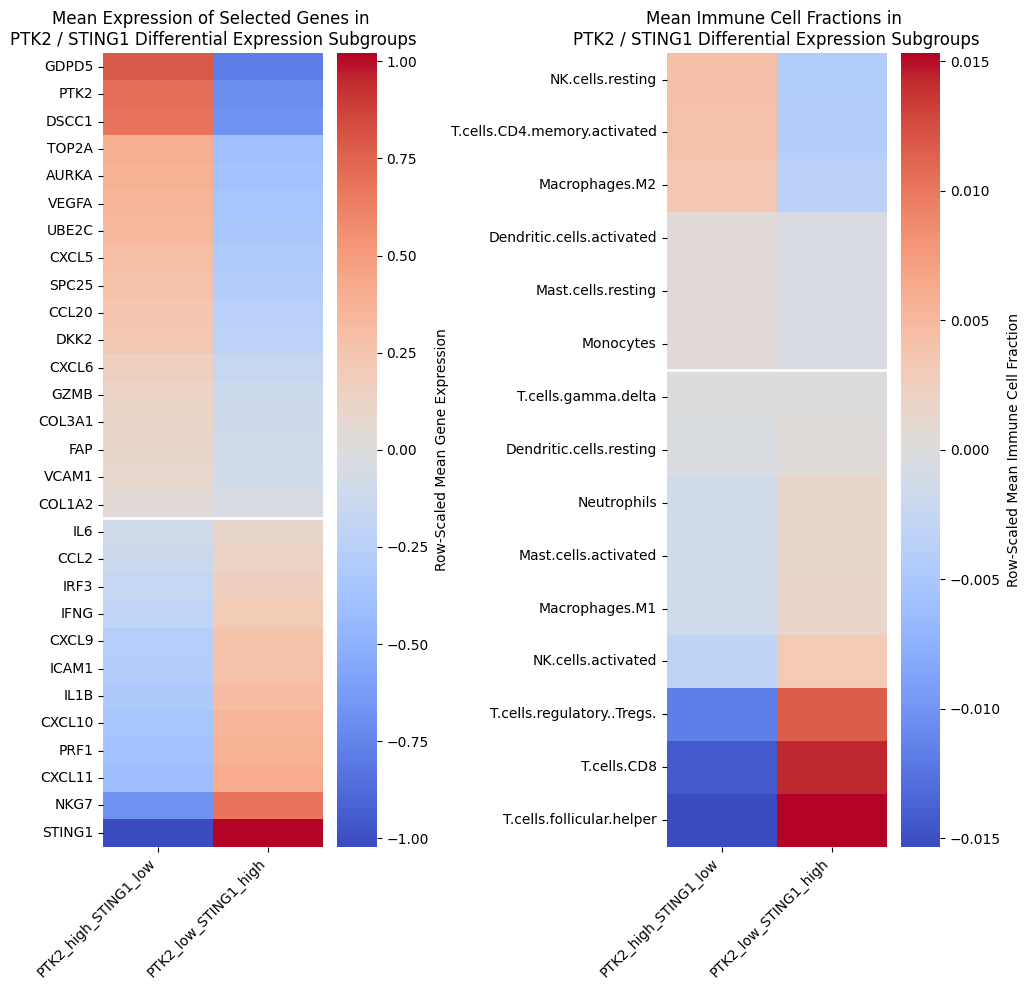

In [35]:
# Sort genes by which group expresses them more
plotted_ptk2_sting1_df = plotted_ptk2_sting1_df.loc[group_means_df["Difference"].sort_values(ascending=False).index]

# Per row scaling for genes
gene_heatmap = plotted_ptk2_sting1_df.sub(plotted_ptk2_sting1_df.mean(axis=1),axis=0)

# Limit to top 20 genes differentially expressed between the two groups for plotting
#gene_heatmap_diff = pd.concat([gene_heatmap.head(20), gene_heatmap.tail(20)], axis=0)
gene_heatmap_diff = gene_heatmap.copy()

# Sort immune populations by which group expresses them more
plotted_ptk2_sting1_immune_populations_df = plotted_ptk2_sting1_immune_populations_df.loc[immune_populations_df["Difference"].sort_values(ascending=False).index]

# Per row scaling for immune populations
immune_populations_heatmap = plotted_ptk2_sting1_immune_populations_df.sub(plotted_ptk2_sting1_immune_populations_df.mean(axis=1),axis=0)

if diagnostic_mode == True:
    print("Top 20 genes with highest mean expression difference:")
    print(tabulate(group_means_df.head(20), headers="keys", tablefmt="github"))

    print("Top 20 immune cell populations with highest mean fraction difference:")
    print(tabulate(immune_populations_df.head(20), headers="keys", tablefmt="github"))

show_plots = True
if show_plots == True:
    plt.figure(figsize=(10, 10))

    plt.subplot(1,2, 1)
    sns.heatmap(gene_heatmap_diff, cmap="coolwarm", center=0, cbar_kws={"label": "Row-Scaled Mean Gene Expression"})
    plt.title('Mean Expression of Selected Genes in \nPTK2 / STING1 Differential Expression Subgroups')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    n_hi_gene = (group_means_df["Difference"] > 0).sum()
    plt.axhline(n_hi_gene, color="white", linewidth=2)

    plt.subplot(1, 2, 2)
    sns.heatmap(immune_populations_heatmap, cmap="coolwarm", center=0, cbar_kws={"label": "Row-Scaled Mean Immune Cell Fraction"})
    plt.title('Mean Immune Cell Fractions in \nPTK2 / STING1 Differential Expression Subgroups')
    plt.xticks(rotation=45, ha='right')
    n_hi_immune_population = (immune_populations_df["Difference"] > 0).sum()
    plt.axhline(n_hi_immune_population, color="white", linewidth=2)

    plt.tight_layout()

    #plt.savefig('PTK2_STING1_Heatmap_differential_gene_expression_immune_populations_short_3.png', dpi=1000, bbox_inches='tight')

    plt.show()


In [36]:
gene_heatmap_diff.to_csv("gene_heatmap_diff.csv")
immune_populations_heatmap.to_csv("immune_populations_heatmap.csv")

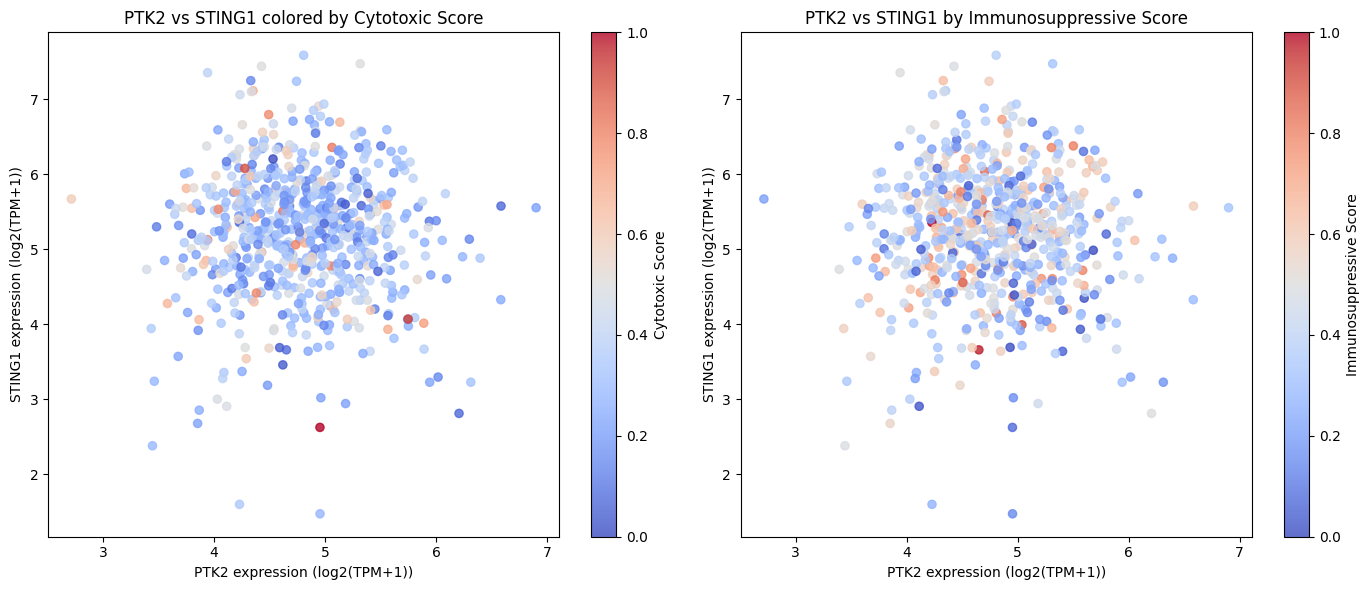

In [37]:
if show_plots == True:
    plt.figure(figsize=(14, 6))

    # Calculate cytotoxic and immunosuppressive scores for each sample based on the defined immune cell populations
    plot_df = expr_cs_merged.copy()
    plot_df["Cytotoxic Score"] = plot_df[cytotoxic_immune_populations].mean(axis=1)
    plot_df["Immunosuppressive Score"] = plot_df[immunosuppressive_immune_populations].mean(axis=1)

    # Normalize scores for better color scaling
    plot_df["Cytotoxic Score"] = (plot_df["Cytotoxic Score"] - 
                                  plot_df["Cytotoxic Score"].min()) / (
                                      plot_df["Cytotoxic Score"].max() - 
                                      plot_df["Cytotoxic Score"].min())
    plot_df["Immunosuppressive Score"] = (plot_df["Immunosuppressive Score"] - 
                                          plot_df["Immunosuppressive Score"].min()) / (
                                              plot_df["Immunosuppressive Score"].max() - 
                                              plot_df["Immunosuppressive Score"].min())

    plt.subplot(1, 2, 1)
    sc = plt.scatter(plot_df["PTK2"],plot_df["STING1"],c=plot_df['Cytotoxic Score'],cmap='coolwarm',s=35,alpha=0.8)
    plt.colorbar(sc, label="Cytotoxic Score")
    plt.xlabel("PTK2 expression (log2(TPM+1))")
    plt.ylabel("STING1 expression (log2(TPM+1))")
    plt.title("PTK2 vs STING1 colored by Cytotoxic Score")

    plt.subplot(1, 2, 2)
    sc = plt.scatter(plot_df["PTK2"],plot_df["STING1"],c=plot_df['Immunosuppressive Score'],cmap='coolwarm',s=35,alpha=0.8)
    plt.colorbar(sc, label="Immunosuppressive Score")
    plt.xlabel("PTK2 expression (log2(TPM+1))")
    plt.ylabel("STING1 expression (log2(TPM+1))")
    plt.title("PTK2 vs STING1 by Immunosuppressive Score")

    plt.savefig('PTK2_STING1_scatter_immune_populations_1.png', dpi=1000, bbox_inches='tight')

    plt.tight_layout()
    plt.show()